============================================================
PROYECTO DATAXPERIENCE - SITP BOGOTA
COMPLEMENTO DEL CODIGO ORIGINAL
============================================================



In [ ]:
# ============================================================
# PASO PREVIO: CARGA Y LIMPIEZA DE LA BASE EN BRUTO (SITP BOGOTÁ)
# ============================================================

import pandas as pd

# 1. Cargar el archivo CSV en bruto (ajusta la ruta según corresponda en tu Drive)
ruta_archivo_bruto = "/content/20260730.csv"
df = pd.read_csv(ruta_archivo_bruto, sep=";")

print("Dimensiones iniciales:", df.shape)

# 2. Normalizar nombres de columnas a minúsculas y reemplazar espacios por guiones bajos
df.columns = [c.lower().strip().replace(" ", "_") for c in df.columns]

# 3. Eliminar columnas que se encuentran 100% vacías o no requeridas para el análisis
columnas_a_borrar = ['id_vehiculo', 'ruta', 'tipo_vehiculo']
df.drop(columns=[col for col in columnas_a_borrar if col in df.columns], inplace=True, errors='ignore')

# 4. Eliminar registros duplicados (reintentos de transmisión en torniquete)
df.drop_duplicates(inplace=True)

# 5. Estandarizar valores de texto (eliminar espacios invisibles y homogenizar nulos)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(['nan', 'None', ''], pd.NA)

# 6. Convertir variables numéricas clave asegurando el formato correcto
if 'valor' in df.columns:
    df['valor'] = pd.to_numeric(df['valor'], errors='coerce')

print("Dimensiones de la base limpia lista para el análisis:", df.shape)
print("¡Limpieza inicial completada con éxito! Ya puedes continuar con el código complementario!")

Dimensiones iniciales: (1048575, 22)
Dimensiones de la base limpia lista para el análisis: (1047338, 19)
¡Limpieza inicial completada con éxito! Ya puedes continuar con el código complementario!


---


In [ ]:
# 13. LIBRERÍAS PARA EL ANÁLISIS COMPLEMENTARIO


---


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
SEED = 42

print("\n============================================")
print("ANÁLISIS COMPLEMENTARIO - PROYECTO SITP")
print("============================================")




ANÁLISIS COMPLEMENTARIO - PROYECTO SITP


---


In [ ]:
# 14. COPIA DE TRABAJO Y VARIABLES TEMPORALES


---


No modificamos el df limpio original de manera destructiva.
Trabajamos sobre una copia para poder volver a utilizar la base limpia.


In [ ]:

analisis = df.copy()

# Aseguramos formato de fecha.
analisis["fecha_transaccion"] = pd.to_datetime(
    analisis["fecha_transaccion"], errors="coerce", dayfirst=True
)

# Primero intentamos obtener la hora desde Fecha_Transaccion.
hora_fecha = analisis["fecha_transaccion"].dt.hour


Después intentamos obtenerla desde Hora_Pico_SN.
Se prueban dos estrategias: conversión directa y extracción del primer
valor que parezca una hora 0-23.


In [ ]:
hora_pico = pd.to_datetime(
    analisis["hora_pico_sn"].astype(str), errors="coerce", format='%H:%M'
).dt.hour

hora_texto = analisis["hora_pico_sn"].astype(str).str.extract(
    r"(?<!\d)([01]?\d|2[0-3])(?::\d{2})?", expand=False
)
hora_texto = pd.to_numeric(hora_texto, errors="coerce")

# Preferimos la hora de la fecha; si no existe, usamos Hora_Pico_SN.
analisis["Hora"] = hora_fecha.fillna(hora_pico).fillna(hora_texto)
analisis["Hora"] = pd.to_numeric(analisis["Hora"], errors="coerce")

print("\nValores de hora obtenidos:")
print("Registros con hora:", analisis["Hora"].notna().sum())
print("Registros sin hora:", analisis["Hora"].isna().sum())


Valores de hora obtenidos:
Registros con hora: 1047337
Registros sin hora: 1


---


In [ ]:
# 15. FRANJAS HORARIAS


---


Las franjas son una transformación analítica, no una variable original.
Se utilizan para facilitar la interpretación y las pruebas de asociación.


In [ ]:

def clasificar_franja(hora):
    if pd.isna(hora):
        return np.nan
    hora = int(hora)
    if 0 <= hora < 6:
        return "Madrugada (00-05)"
    elif 6 <= hora < 12:
        return "Mañana (06-11)"
    elif 12 <= hora < 18:
        return "Tarde (12-17)"
    else:
        return "Noche (18-23)"

analisis["Franja_Horaria"] = analisis["Hora"].apply(clasificar_franja)

orden_franjas = [
    "Madrugada (00-05)",
    "Mañana (06-11)",
    "Tarde (12-17)",
    "Noche (18-23)"
]

analisis["Franja_Horaria"] = pd.Categorical(
    analisis["Franja_Horaria"],
    categories=orden_franjas,
    ordered=True
)



---


In [ ]:
# 16. PREGUNTA 1 - ESTACIONES CON MÁS VALIDACIONES


---



PREGUNTA 1 - ESTACIONES CON MÁS VALIDACIONES
                               Estacion_Parada  Validaciones
                       (05000) Portal Américas         62331
       (07000) Portal Sur JFK Coop. Financiera         48590
                           (03000) Portal Suba         45525
           (02000) Portal Norte - Unicervantes         44696
                         (09000) Cabecera Usme         43028
                     (04000) Cabecera Calle 80         38154
                    (10000) Portal 20 de Julio         35179
               (07503) SAN MATEO - C.C. UNISUR         34891
                          (08000) Portal Tunal         31999
                   (05100) Banderas P. Central         28195
(06000) Portal El Dorado - C.C. NUESTRO BOGOTA         27995
                              (07504) TERREROS         25245
                  (50008) Corral Portal Dorado         21708
                                (05002) Tintal         17323
                               (02101) 

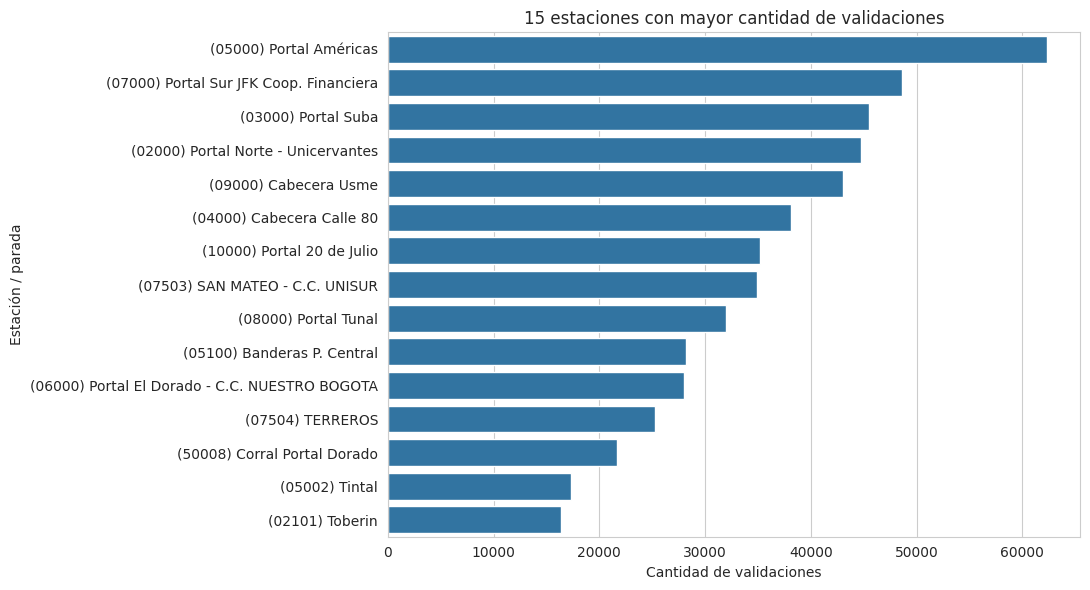

In [ ]:
print("\n============================================")
print("PREGUNTA 1 - ESTACIONES CON MÁS VALIDACIONES")
print("============================================")

top_estaciones = (
    analisis["estacion_parada"]
    .value_counts()
    .head(15)
    .rename_axis("Estacion_Parada")
    .reset_index(name="Validaciones")
)

print(top_estaciones.to_string(index=False))

plt.figure(figsize=(11, 6))
sns.barplot(
    data=top_estaciones,
    y="Estacion_Parada",
    x="Validaciones"
)
plt.title("15 estaciones con mayor cantidad de validaciones")
plt.xlabel("Cantidad de validaciones")
plt.ylabel("Estación / parada")
plt.tight_layout()
plt.show()


---


In [ ]:
# 17. PREGUNTA 2 - HORARIOS DE MAYOR CONCENTRACIÓN


---



PREGUNTA 2 - CONCENTRACIÓN HORARIA
Hora con mayor cantidad de validaciones:
06:00 -> 201,873 validaciones

Top 5 horas:
 Hora  Validaciones
    6        201873
    7        175155
    5        122541
    8        116137
    9         84194


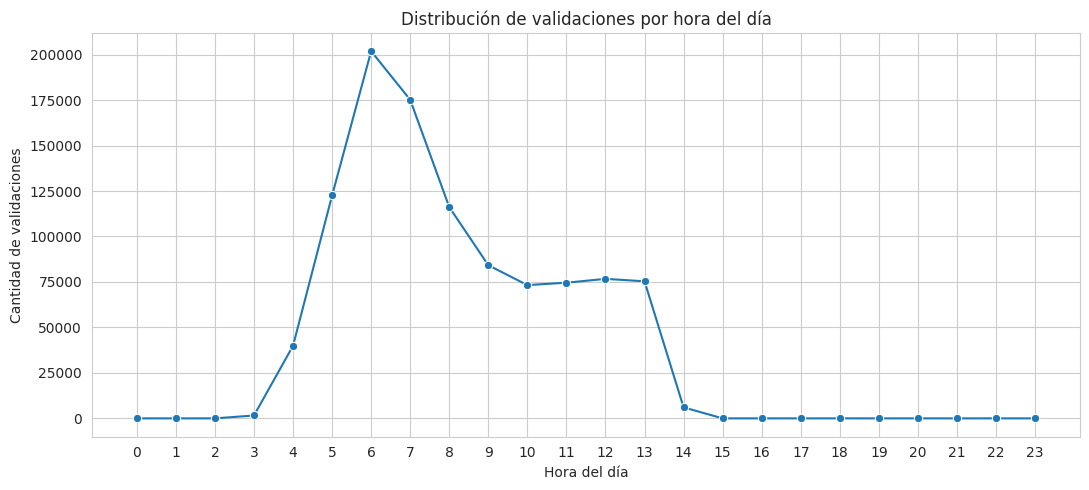


Validaciones por franja horaria:
   Franja_Horaria  Validaciones
Madrugada (00-05)        164027
   Mañana (06-11)        725216
    Tarde (12-17)        158094
    Noche (18-23)             0


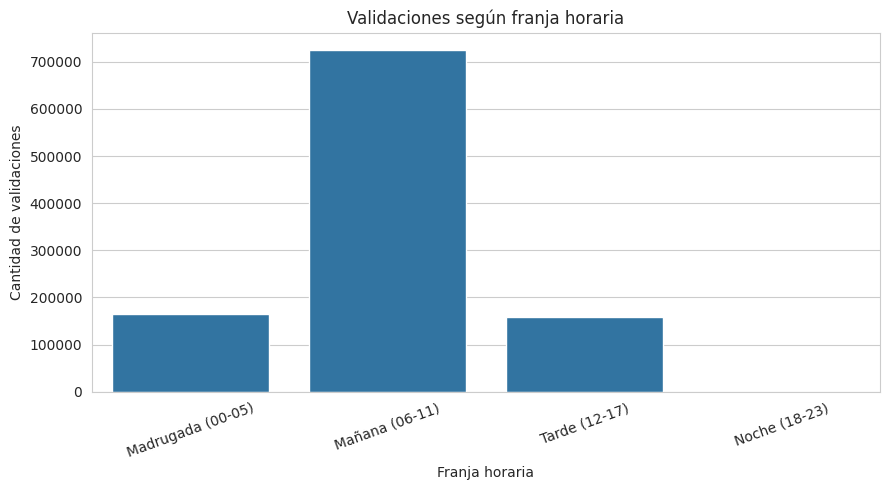

In [ ]:
print("\n============================================")
print("PREGUNTA 2 - CONCENTRACIÓN HORARIA")
print("============================================")

validaciones_hora = (
    analisis.dropna(subset=["Hora"])
    .groupby("Hora")
    .size()
    .reindex(range(24), fill_value=0)
    .rename("Validaciones")
    .reset_index()
)

validaciones_hora["Hora"] = validaciones_hora["Hora"].astype(int)

hora_max = validaciones_hora.loc[
    validaciones_hora["Validaciones"].idxmax()
]

print("Hora con mayor cantidad de validaciones:")
print(f"{int(hora_max['Hora']):02d}:00 -> {int(hora_max['Validaciones']):,} validaciones")

print("\nTop 5 horas:")
print(
    validaciones_hora
    .sort_values("Validaciones", ascending=False)
    .head(5)
    .to_string(index=False)
)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=validaciones_hora,
    x="Hora",
    y="Validaciones",
    marker="o"
)
plt.xticks(range(24))
plt.title("Distribución de validaciones por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de validaciones")
plt.tight_layout()
plt.show()

# Franja horaria
validaciones_franja = (
    analisis.dropna(subset=["Franja_Horaria"])
    .groupby("Franja_Horaria", observed=False)
    .size()
    .reindex(orden_franjas, fill_value=0)
    .rename("Validaciones")
    .reset_index()
)

print("\nValidaciones por franja horaria:")
print(validaciones_franja.to_string(index=False))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=validaciones_franja,
    x="Franja_Horaria",
    y="Validaciones"
)
plt.title("Validaciones según franja horaria")
plt.xlabel("Franja horaria")
plt.ylabel("Cantidad de validaciones")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



---


In [ ]:
# 18. PREGUNTA 3 - TIPO DE TARJETA MÁS UTILIZADO


---



PREGUNTA 3 - TIPO DE TARJETA
  Tipo_Tarjeta  Validaciones  Porcentaje
  tullave Plus        738065   70.470632
tullave Básica        309272   29.529368


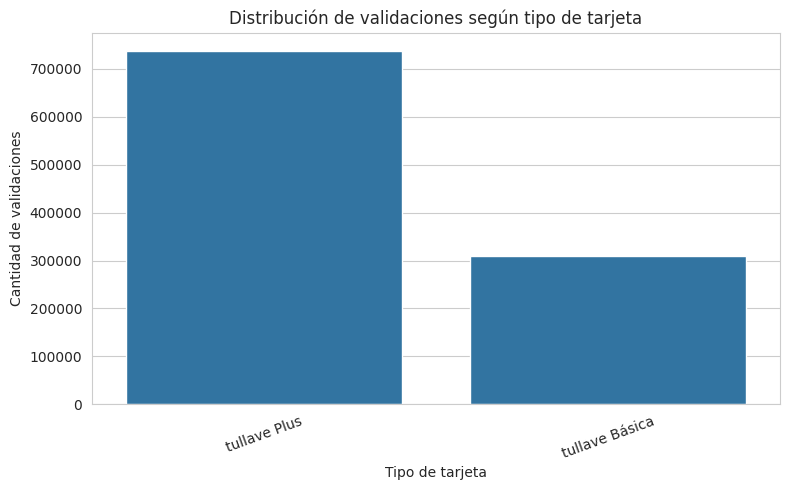

In [ ]:
print("\n============================================")
print("PREGUNTA 3 - TIPO DE TARJETA")
print("============================================")

tarjetas = (
    analisis["tipo_tarjeta"]
    .value_counts()
    .rename_axis("Tipo_Tarjeta")
    .reset_index(name="Validaciones")
)

tarjetas["Porcentaje"] = (
    tarjetas["Validaciones"] / tarjetas["Validaciones"].sum() * 100
)

print(tarjetas.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(
    data=tarjetas,
    x="Tipo_Tarjeta",
    y="Validaciones"
)
plt.title("Distribución de validaciones según tipo de tarjeta")
plt.xlabel("Tipo de tarjeta")
plt.ylabel("Cantidad de validaciones")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


---


In [ ]:
# 19. PREGUNTA 4 - PERFIL DE USUARIO MÁS FRECUENTE


---



PREGUNTA 4 - PERFIL DE USUARIO
                     Nombre_Perfil  Validaciones  Porcentaje
                      (001) Adulto        524518   50.081110
                   (001) Anonymous        309272   29.529368
                (002) Adulto Mayor         93704    8.946881
             (006) Apoyo Ciudadano         41110    3.925193
(009) Apoyo Ciudadano Reexpedición         31210    2.979939
                   (101) Adulto PV         30687    2.930002
                (005) Discapacidad         16836    1.607506


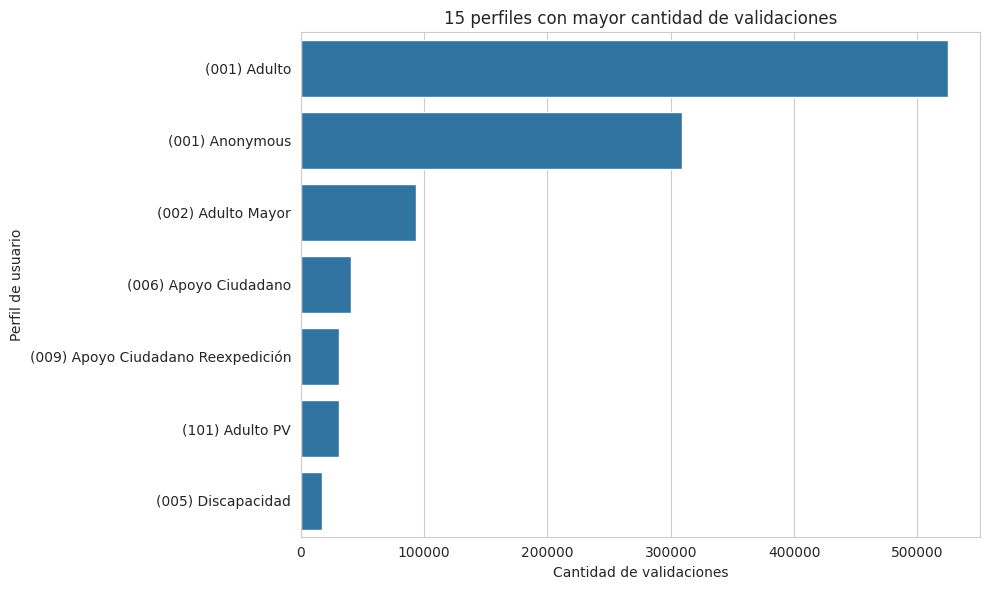

In [ ]:
print("\n============================================")
print("PREGUNTA 4 - PERFIL DE USUARIO")
print("===========================================")

perfiles = (
    analisis["nombre_perfil"]
    .value_counts()
    .head(15)
    .rename_axis("Nombre_Perfil")
    .reset_index(name="Validaciones")
)

perfiles["Porcentaje"] = (
    perfiles["Validaciones"] / analisis["nombre_perfil"].notna().sum() * 100
)

print(perfiles.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=perfiles,
    y="Nombre_Perfil",
    x="Validaciones"
)
plt.title("15 perfiles con mayor cantidad de validaciones")
plt.xlabel("Cantidad de validaciones")
plt.ylabel("Perfil de usuario")
plt.tight_layout()
plt.show()


---


In [ ]:
# 20. ANÁLISIS ESTADÍSTICO - DESCRIPTIVOS DE VALOR


---



ANÁLISIS ESTADÍSTICO DE LA VARIABLE VALOR
Media                        2946.711
Mediana                      3550.000
Desviacion_estandar          1333.312
Minimo                          0.000
Q1                           3550.000
Q3                           3550.000
IQR                             0.000
Maximo                       3550.000
Skewness                       -1.758
Curtosis                        1.089
Cantidad_atipicos_Tukey    177985.000
dtype: float64


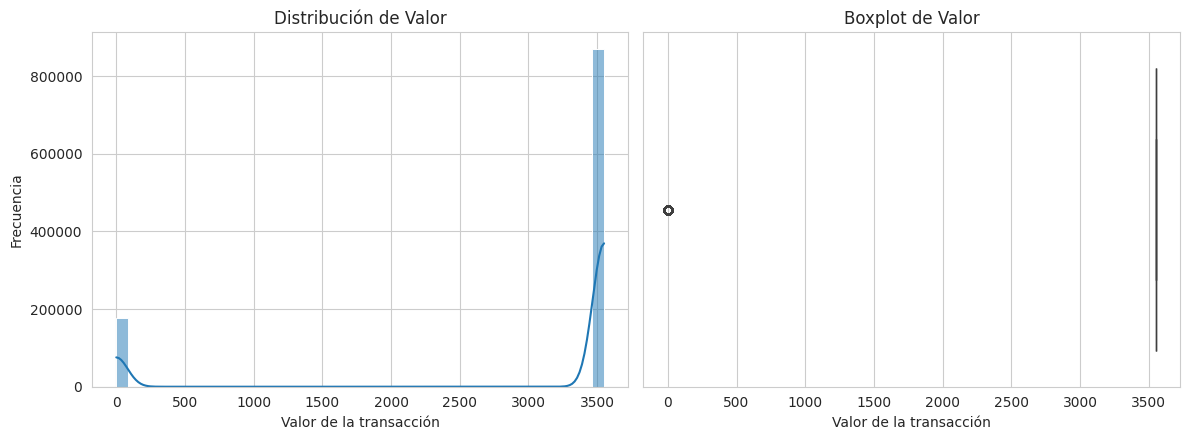

In [ ]:
print("\n============================================")
print("ANÁLISIS ESTADÍSTICO DE LA VARIABLE VALOR")
print("===========================================")

valor = pd.to_numeric(analisis["valor"], errors="coerce").dropna()

q1 = valor.quantile(0.25)
q3 = valor.quantile(0.75)
iqr = q3 - q1
bigote_inf = q1 - 1.5 * iqr
bigote_sup = q3 + 1.5 * iqr
atipicos = valor[(valor < bigote_inf) | (valor > bigote_sup)]

resumen_valor = pd.Series({
    "Media": valor.mean(),
    "Mediana": valor.median(),
    "Desviacion_estandar": valor.std(ddof=1),
    "Minimo": valor.min(),
    "Q1": q1,
    "Q3": q3,
    "IQR": iqr,
    "Maximo": valor.max(),
    "Skewness": valor.skew(),
    "Curtosis": valor.kurtosis(),
    "Cantidad_atipicos_Tukey": len(atipicos)
})

print(resumen_valor.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(valor, bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribución de Valor")
axes[0].set_xlabel("Valor de la transacción")
axes[0].set_ylabel("Frecuencia")

sns.boxplot(x=valor, ax=axes[1])
axes[1].set_title("Boxplot de Valor")
axes[1].set_xlabel("Valor de la transacción")

plt.tight_layout()
plt.show()


---


In [ ]:
# 21. RELACIONES: TARJETA VS PERFIL Y TARJETA VS FRANJA


---


In [ ]:

# Chi-cuadrado: tipo de tarjeta vs perfil de usuario
base_chi_1 = analisis[["tipo_tarjeta", "nombre_perfil"]].dropna()
tabla_tarjeta_perfil = pd.crosstab(
    base_chi_1["tipo_tarjeta"],
    base_chi_1["nombre_perfil"]
)

chi2_1, p_1, dof_1, expected_1 = st.chi2_contingency(tabla_tarjeta_perfil)

print("Chi-cuadrado: Tipo_Tarjeta vs Nombre_Perfil")
print("Chi2:", round(chi2_1, 3))
print("gl:", dof_1)
print("p-valor:", p_1)
print(
    "Interpretación:",
    "hay evidencia de asociación (p < 0.05)"
    if p_1 < 0.05
    else "no hay evidencia suficiente de asociación (p >= 0.05)"
)

# Chi-cuadrado: tipo de tarjeta vs franja horaria
base_chi_2 = analisis[["tipo_tarjeta", "Franja_Horaria"]].dropna()
tabla_tarjeta_franja = pd.crosstab(
    base_chi_2["tipo_tarjeta"],
    base_chi_2["Franja_Horaria"]
)

chi2_2, p_2, dof_2, expected_2 = st.chi2_contingency(tabla_tarjeta_franja)

print("\nChi-cuadrado: Tipo_Tarjeta vs Franja_Horaria")
print("Chi2:", round(chi2_2, 3))
print("gl:", dof_2)
print("p-valor:", p_2)
print(
    "Interpretación:",
    "hay evidencia de asociación (p < 0.05)"
    if p_2 < 0.05
    else "no hay evidencia suficiente de asociación (p >= 0.05)"
)


Chi-cuadrado: Tipo_Tarjeta vs Nombre_Perfil
Chi2: 1047337.0
gl: 6
p-valor: 0.0
Interpretación: hay evidencia de asociación (p < 0.05)

Chi-cuadrado: Tipo_Tarjeta vs Franja_Horaria
Chi2: 1019.671
gl: 2
p-valor: 3.8130827201860994e-222
Interpretación: hay evidencia de asociación (p < 0.05)


---


In [ ]:
# 22. PREGUNTA 5 - DIFERENCIAS SEGÚN ESTACIÓN Y HORARIO


---


In [ ]:
print("\n============================================")
print("PREGUNTA 5 - ESTACIÓN Y HORARIO")
print("============================================")




PREGUNTA 5 - ESTACIÓN Y HORARIO


La pregunta original menciona "zona". La base limpia documentada en el proyecto
NO contiene una variable explícita de zona geográfica. Por rigor, no se inventa una.


NOTA METODOLÓGICA: la pregunta original menciona zona, pero las 19 columnas documentadas en el PDF no contienen una variable explícita de zona geográfica. Por tanto, el análisis se limita a estación y horario.

Tabla de contingencia - Top 10 estaciones x franja:
Franja_Horaria                           Madrugada (00-05)  Mañana (06-11)  \
estacion_parada                                                              
(02000) Portal Norte - Unicervantes                   5023           34379   
(03000) Portal Suba                                   7792           33802   
(04000) Cabecera Calle 80                             4510           29459   
(05000) Portal Américas                              17844           39794   
(05100) Banderas P. Central                           4295           20933   
(07000) Portal Sur JFK Coop. Financiera              12227           32435   
(07503) SAN MATEO - C.C. UNISUR                      10871           21647   
(08000) Portal Tunal               

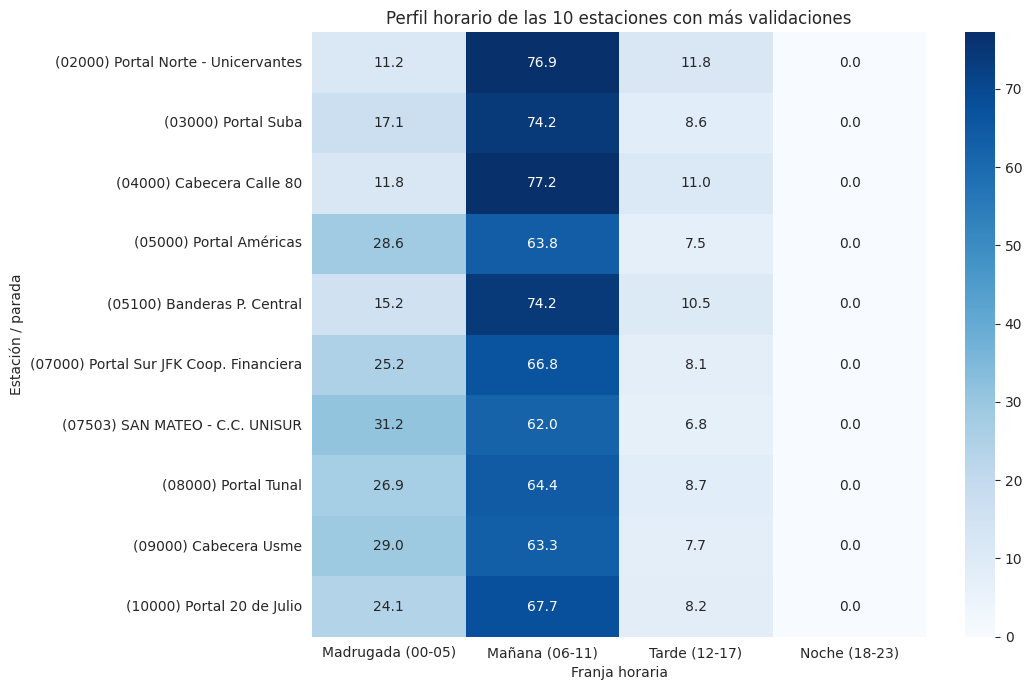

In [ ]:
print(
    "NOTA METODOLÓGICA: la pregunta original menciona zona, pero las 19 columnas "
    "documentadas en el PDF no contienen una variable explícita de zona geográfica. "
    "Por tanto, el análisis se limita a estación y horario."
)

# Para evitar una tabla inmanejable, usamos las 10 estaciones principales.
top10_nombres = top_estaciones.head(10)["Estacion_Parada"].tolist()
base_estacion_hora = analisis[
    analisis["estacion_parada"].isin(top10_nombres)
][["estacion_parada", "Franja_Horaria"]].dropna()

tabla_estacion_hora = pd.crosstab(
    base_estacion_hora["estacion_parada"],
    base_estacion_hora["Franja_Horaria"]
).reindex(columns=orden_franjas, fill_value=0)

# Create a filtered version of the table for the chi-squared test
# Exclude 'Noche (18-23)' as it has zero total validations (from `validaciones_franja`)
# and causes zero expected frequencies, leading to ValueError.
tabla_estacion_hora_filtered = tabla_estacion_hora.drop(columns=['Noche (18-23)'], errors='ignore')

# Remove any rows that might have become all zeros after dropping the 'Noche (18-23)' column,
# as these would also lead to issues in chi-squared calculation.
tabla_estacion_hora_filtered = tabla_estacion_hora_filtered.loc[(tabla_estacion_hora_filtered != 0).any(axis=1)]

# Ensure the filtered table is still valid for chi-squared test (at least 2x2)
if tabla_estacion_hora_filtered.shape[0] >= 2 and tabla_estacion_hora_filtered.shape[1] >= 2:
    chi2_3, p_3, dof_3, expected_3 = st.chi2_contingency(tabla_estacion_hora_filtered)
else:
    print("Advertencia: La tabla de contingencia filtrada tiene datos insuficientes para realizar la prueba de Chi-cuadrado. Resultados serán NaN.")
    chi2_3, p_3, dof_3, expected_3 = np.nan, np.nan, np.nan, np.nan

print("\nTabla de contingencia - Top 10 estaciones x franja:")
print(tabla_estacion_hora)
print("\nChi-cuadrado: Estacion_Parada vs Franja_Horaria")
# Only print results if the test was performed successfully
if not np.isnan(chi2_3):
    print("Chi2:", round(chi2_3, 3))
    print("gl:", dof_3)
    print("p-valor:", p_3)
    print(
        "Interpretación:",
        "hay evidencia de asociación entre estación y franja horaria (p < 0.05)"
        if p_3 < 0.05
        else "no hay evidencia suficiente de asociación (p >= 0.05)"
    )
else:
    print("No se pudo realizar la prueba de Chi-cuadrado debido a datos insuficientes o cero en las frecuencias esperadas.")

# Porcentajes dentro de cada estación para comparar perfiles horarios.
proporciones_estacion_hora = tabla_estacion_hora.div(
    tabla_estacion_hora.sum(axis=1), axis=0
) * 100

plt.figure(figsize=(11, 7))
sns.heatmap(
    proporciones_estacion_hora,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)
plt.title("Perfil horario de las 10 estaciones con más validaciones")
plt.xlabel("Franja horaria")
plt.ylabel("Estación / parada")
plt.tight_layout()
plt.show()


---


In [ ]:
# 23. K-MEANS: SEGMENTACIÓN DE ESTACIONES


---


In [ ]:
print("\n============================================")
print("MODELO K-MEANS - SEGMENTACIÓN DE ESTACIONES")
print("============================================")



Unidad de análisis del modelo: ESTACIÓN, no transacción.
Esto evita que las estaciones con más registros aparezcan miles de veces.


In [ ]:

base_horas = analisis.dropna(subset=["Hora"]).copy()
base_horas["Hora"] = base_horas["Hora"].astype(int)

# Conteo por estación y hora.
tabla_estacion_hora_24 = pd.crosstab(
    base_horas["estacion_parada"],
    base_horas["Hora"]
).reindex(columns=range(24), fill_value=0)


Convertimos los conteos en proporciones horarias.
Así el modelo puede comparar la FORMA del comportamiento horario
y no solamente el tamaño bruto de la estación.


In [ ]:
perfil_horario = tabla_estacion_hora_24.div(
    tabla_estacion_hora_24.sum(axis=1), axis=0
).fillna(0)

# Intensidad total de la estación.
intensidad = tabla_estacion_hora_24.sum(axis=1).rename("Total_Validaciones")

# Valor medio de transacción por estación, si existe información válida.
valor_estacion = (
    pd.to_numeric(base_horas["valor"], errors="coerce")
    .groupby(base_horas["estacion_parada"])
    .mean()
    .rename("Valor_Promedio")
)

# Construimos la matriz de características.
features_cluster = perfil_horario.copy()
features_cluster["Log_Total_Validaciones"] = np.log1p(intensidad)
features_cluster["Valor_Promedio"] = valor_estacion
features_cluster = features_cluster.replace([np.inf, -np.inf], np.nan).dropna()

print("Número de estaciones disponibles para clustering:", len(features_cluster))
print("Número de variables del modelo:", features_cluster.shape[1])

# Convertir todos los nombres de las columnas a string para evitar TypeError en StandardScaler.
features_cluster.columns = features_cluster.columns.astype(str)

# Estandarización, siguiendo el enfoque de los notebooks.
escalador_cluster = StandardScaler()
X_cluster = escalador_cluster.fit_transform(features_cluster)


Número de estaciones disponibles para clustering: 147
Número de variables del modelo: 26


---


In [ ]:
# 24. SELECCIÓN DE K: CODO + SILUETA


---



Comparación de K:
 K      WCSS  Silhouette
 2 1115.3908      0.4009
 3  802.9232      0.3909
 4  673.1371      0.2996
 5  597.6367      0.2921
 6  531.8783      0.2725
 7  488.3511      0.2426
 8  448.6808      0.2391

K recomendado por mayor silhouette: 2


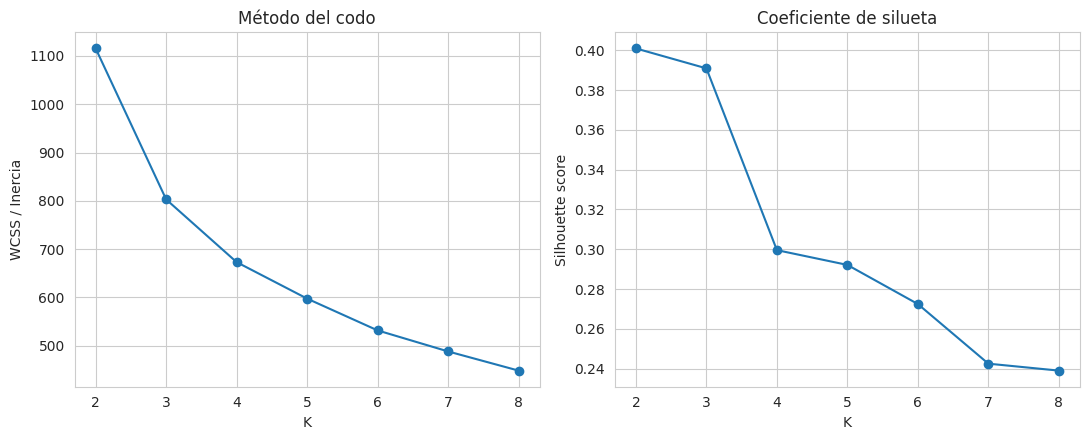

In [ ]:

wcss = []
siluetas = []
rango_k = range(2, 9)

for k in rango_k:
    km = KMeans(
        n_clusters=k,
        random_state=SEED,
        n_init=10
    )
    labels = km.fit_predict(X_cluster)
    wcss.append(km.inertia_)
    siluetas.append(silhouette_score(X_cluster, labels))

resultados_kmeans = pd.DataFrame({
    "K": list(rango_k),
    "WCSS": wcss,
    "Silhouette": siluetas
})

print("\nComparación de K:")
print(resultados_kmeans.round(4).to_string(index=False))

k_silueta = int(
    resultados_kmeans.loc[
        resultados_kmeans["Silhouette"].idxmax(), "K"
    ]
)

print("\nK recomendado por mayor silhouette:", k_silueta)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(resultados_kmeans["K"], resultados_kmeans["WCSS"], marker="o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("WCSS / Inercia")
axes[0].set_title("Método del codo")

axes[1].plot(resultados_kmeans["K"], resultados_kmeans["Silhouette"], marker="o")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Coeficiente de silueta")

plt.tight_layout()
plt.show()



---


In [ ]:
# 25. MODELO FINAL K-MEANS


---


In [ ]:

kmeans_final = KMeans(
    n_clusters=k_silueta,
    random_state=SEED,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_cluster)

estaciones_cluster = features_cluster.copy()
estaciones_cluster["Cluster"] = clusters

print("\nSilhouette del modelo final:", round(
    silhouette_score(X_cluster, clusters), 4
))
print("Inercia del modelo final:", round(kmeans_final.inertia_, 2))

print("\nCantidad de estaciones por cluster:")
print(estaciones_cluster["Cluster"].value_counts().sort_index())




Silhouette del modelo final: 0.4009
Inercia del modelo final: 1115.39

Cantidad de estaciones por cluster:
Cluster
0    75
1    72
Name: count, dtype: int64


---


In [ ]:
# 26. PERFIL DE LOS CLUSTERS


---


In [ ]:

perfil_clusters = estaciones_cluster.groupby("Cluster").agg(
    Estaciones=("Cluster", "size"),
    Total_Validaciones_Mediana=("Log_Total_Validaciones", "median"),
    Valor_Promedio_Mediano=("Valor_Promedio", "median")
).reset_index()

# Volvemos a la escala original para interpretar la intensidad.
perfil_clusters["Total_Validaciones_Mediana"] = (
    np.expm1(perfil_clusters["Total_Validaciones_Mediana"])
)

print("\nPerfil general de los clusters:")
print(perfil_clusters.round(2).to_string(index=False))

# Top estaciones de cada cluster.
print("\nEjemplos de estaciones por cluster:")
for cluster in sorted(estaciones_cluster["Cluster"].unique()):
    estaciones_ejemplo = (
        estaciones_cluster[estaciones_cluster["Cluster"] == cluster]
        .join(intensidad.rename("Total_Validaciones"))
        .sort_values("Total_Validaciones", ascending=False)
        .head(10)
    )
    print(f"\nCluster {cluster}:")
    print(estaciones_ejemplo[["Total_Validaciones"]].head(10))




Perfil general de los clusters:
 Cluster  Estaciones  Total_Validaciones_Mediana  Valor_Promedio_Mediano
       0          75                     5582.00                 2978.43
       1          72                     2718.33                 3343.86

Ejemplos de estaciones por cluster:

Cluster 0:
                                         Total_Validaciones
estacion_parada                                            
(05000) Portal Américas                               62331
(07000) Portal Sur JFK Coop. Financiera               48590
(03000) Portal Suba                                   45525
(02000) Portal Norte - Unicervantes                   44696
(09000) Cabecera Usme                                 43028
(04000) Cabecera Calle 80                             38154
(10000) Portal 20 de Julio                            35179
(07503) SAN MATEO - C.C. UNISUR                       34891
(08000) Portal Tunal                                  31999
(05100) Banderas P. Central            

---


In [ ]:
# 27. PCA PARA VISUALIZAR LOS CLUSTERS EN 2D


---



Varianza explicada por PCA:
[0.5829 0.1795]
Varianza acumulada por las dos componentes: 0.7624


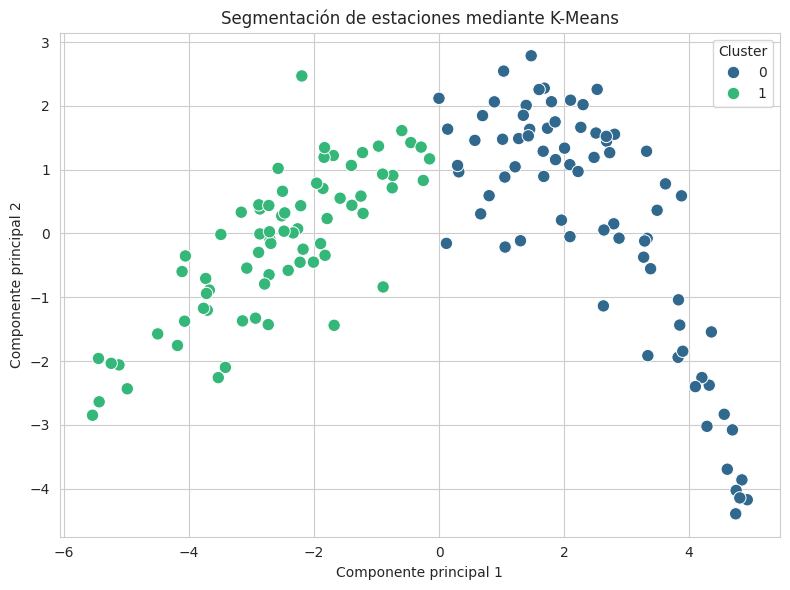

In [ ]:

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_cluster)

visual_clusters = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clusters
})

print("\nVarianza explicada por PCA:")
print(np.round(pca.explained_variance_ratio_, 4))
print(
    "Varianza acumulada por las dos componentes:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=visual_clusters,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    s=80
)
plt.title("Segmentación de estaciones mediante K-Means")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()



---


In [ ]:
# 28. GUARDAR RESULTADOS


---


In [ ]:
import os

ruta_salida = "/content/drive/MyDrive/Proyecto Data/"

# Crear el directorio si no existe
os.makedirs(ruta_salida, exist_ok=True)

top_estaciones.to_csv(
    ruta_salida + "resultado_top_estaciones.csv",
    index=False,
    sep=";"
)

validaciones_hora.to_csv(
    ruta_salida + "resultado_validaciones_hora.csv",
    index=False,
    sep=";"
)

tarjetas.to_csv(
    ruta_salida + "resultado_tipo_tarjeta.csv",
    index=False,
    sep=";"
)

perfiles.to_csv(
    ruta_salida + "resultado_perfiles.csv",
    index=False,
    sep=";"
)

resultados_kmeans.to_csv(
    ruta_salida + "resultado_kmeans_k.csv",
    index=False,
    sep=";"
)

estaciones_cluster.reset_index().to_csv(
    ruta_salida + "resultado_estaciones_clusters.csv",
    index=False,
    sep=";"
)

print("\nResultados guardados en Google Drive.")


Resultados guardados en Google Drive.


---


In [ ]:
# 29. RESUMEN FINAL AUTOMÁTICO


---


In [ ]:
print("\n============================================")
print("RESUMEN DE RESULTADOS A REPORTAR")
print("============================================")

print("1. Estación líder:", top_estaciones.iloc[0]["Estacion_Parada"])
print("   Validaciones:", int(top_estaciones.iloc[0]["Validaciones"]))

print(
    "2. Hora líder:",
    f"{int(hora_max['Hora']):02d}:00",
    "con",
    int(hora_max["Validaciones"]),
    "validaciones"
)

print("3. Tarjeta más utilizada:", tarjetas.iloc[0]["Tipo_Tarjeta"])
print("   Participación:", round(tarjetas.iloc[0]["Porcentaje"], 2), "%")

print("4. Perfil más frecuente:", perfiles.iloc[0]["Nombre_Perfil"])
print("   Validaciones:", int(perfiles.iloc[0]["Validaciones"]))

print("5. Zona geográfica:")
print("   NO SE RESPONDE con la base actual porque no existe una variable explícita de zona.")

print("6. K-Means:")
print("   K seleccionado por silhouette:", k_silueta)
print("   Silhouette final:", round(silhouette_score(X_cluster, clusters), 4))

print("\nFIN DEL ANÁLISIS COMPLEMENTARIO")



RESUMEN DE RESULTADOS A REPORTAR
1. Estación líder: (05000) Portal Américas
   Validaciones: 62331
2. Hora líder: 06:00 con 201873 validaciones
3. Tarjeta más utilizada: tullave Plus
   Participación: 70.47 %
4. Perfil más frecuente: (001) Adulto
   Validaciones: 524518
5. Zona geográfica:
   NO SE RESPONDE con la base actual porque no existe una variable explícita de zona.
6. K-Means:
   K seleccionado por silhouette: 2
   Silhouette final: 0.4009

FIN DEL ANÁLISIS COMPLEMENTARIO
